In [1]:
import os

# Core LSD imports
from sclsd.train import LSD
from sclsd.plotting import plot_random_walks

from sclsd.core import LSDConfig
from sclsd.utils import set_all_seeds
from sclsd.utils.seed import clear_pyro_state

# Deep learning
import torch

# Single-cell analysis
import scanpy as sc


print(f"PyTorch version: {torch.__version__}")
print(f"Scanpy version: {sc.__version__}")

/scratch/apour/conda/envs/sclsd/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch version: 2.4.1+cu121
Scanpy version: 1.11.5


/projects/apour/.cache/tmp/ipykernel_2901843/209599165.py:19: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print(f"Scanpy version: {sc.__version__}")


In [2]:
# Configure computational device
device = torch.device("cuda:2" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
SEED = 42
set_all_seeds(SEED)

Using device: cuda:2


In [3]:
# Load preprocessed pancreas data with prior pseudotime
data_path = "../../Zenodo/Pancreas/preprocessed_adata.h5ad"
adata = sc.read(data_path)

In [4]:
# Define the pancreatic endocrine differentiation phylogeny
# This represents the established developmental progression
phylogeny = {
    "Prlf. Ductal":      ["Ductal"],                    # Proliferating to quiescent ductal
    "Ductal":            ["Ngn3 low"],                  # Ductal to early endocrine progenitor
    "Ngn3 low":          ["Ngn3 high"],                 # Progenitor maturation
    "Ngn3 high":         ['Fev+','Fev+ Delta','Epsilon'], # Multi-lineage branching
    "Fev+":              ['Fev+ Alpha','Fev+ Beta'],    # Alpha/Beta lineage split
    "Fev+ Delta":        ["Delta"],                     # Delta maturation
    "Fev+ Alpha":        ["Alpha"],                     # Alpha maturation
    "Fev+ Beta":         ["Beta"],                      # Beta maturation
    "Epsilon":           [],                            # Terminal epsilon cells
    "Alpha":             [],                            # Terminal alpha cells (glucagon)
    "Beta":              [],                            # Terminal beta cells (insulin)
    "Delta":             [],                            # Terminal delta cells (somatostatin)
}


# Validate phylogeny coverage
phylo_clusters = set(phylogeny.keys())
data_clusters = set(adata.obs['clusters'].unique())

## Section 7: Model Initialization

[LSD] Removing 52 cells with no transitions:
[LSD] Prior transition matrix set from phylogeny and pseudotime.


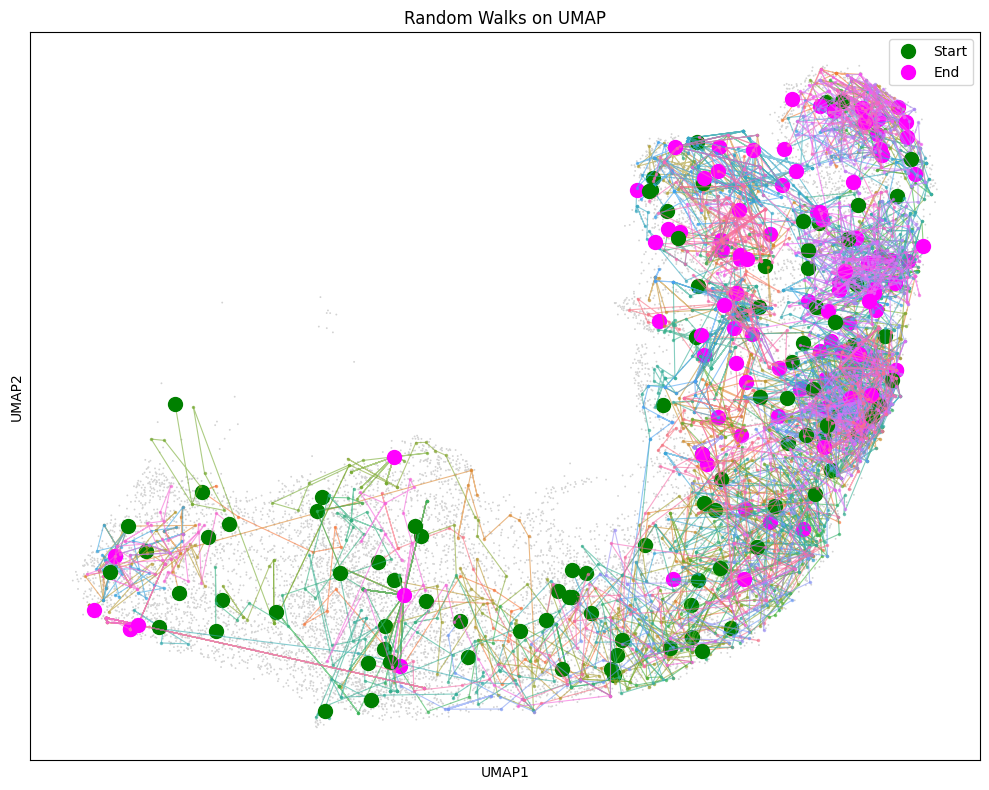

In [5]:
# Initialize the LSD model
cfg = LSDConfig()

cfg.model.V_coeff = 5e-3
cfg.optimizer.kl_schedule.af = 3
cfg.optimizer.adam.lr = 2e-3
cfg.walks.path_len = 50
cfg.walks.random_state = SEED



lsd = LSD(
    adata,
    cfg,            
    device=device,                   
)


# Set phylogenetic relationships
lsd.set_phylogeny(phylogeny, cluster_key="clusters")
# Set prior pseudotime key
lsd.set_prior_transition(prior_time_key="prior_time")
# Prepare walks on the cell connectivity graph
lsd.prepare_walks()
# Visualize a subset of random walks
plot_random_walks(lsd.adata, lsd.walks[:100], "X_umap")

Training Epochs: 100%|██████████| 100/100 [20:19<00:00, 12.19s/it, -ELBO=1.4282, Potential Metric=0.2799, Entropy Metric=0.0592]


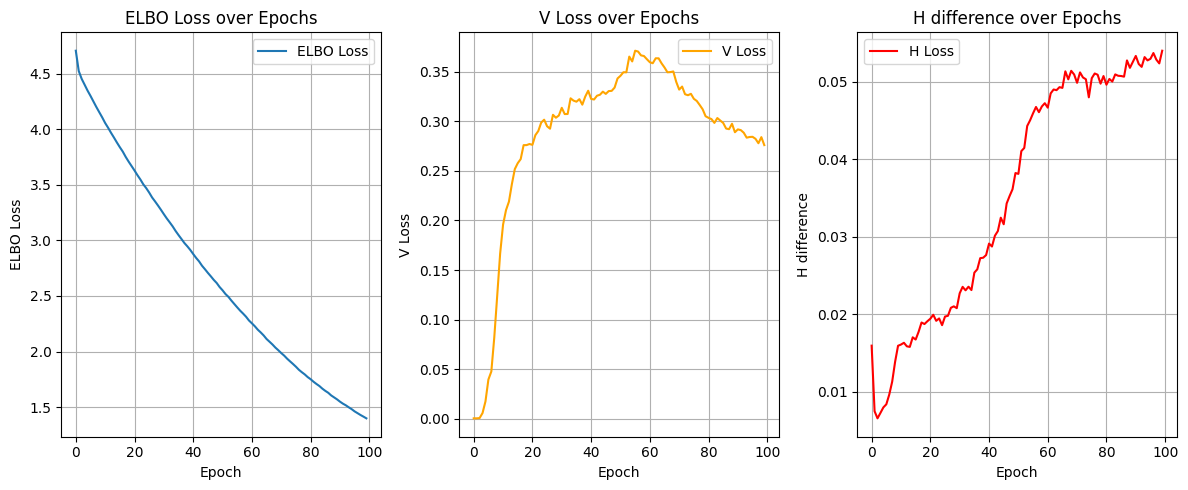

In [6]:
# Define model directory based on hyperparameters
model_dir = "./model"

# Clear parameter store for fresh training
clear_pyro_state()
# Create save directory
os.makedirs(model_dir, exist_ok=True)
num_epochs = 100     # Total training epochs
# Train the model
lsd.train(
    num_epochs=num_epochs,
    save_dir=model_dir,
    random_state=SEED
)